In [7]:
import torch
import sys

print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    x = torch.ones(1).cuda()
    print(f"GPU Test: Successful")
else:
    print("GPU Test: CUDA not detected. Check NVIDIA drivers.")

Python Version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
PyTorch Version: 2.5.1
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Test: Successful


In [7]:
import sys
import os
import torch
import torch.nn as nn
from PIL import Image, ImageDraw
import torchvision.transforms as T
import numpy as np

# --- STEP 1: FIX PATHS (Crucial for src.core) ---
# Set this to your project root folder
ROOT_DIR = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2'
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
os.chdir(ROOT_DIR)

# Update these to your actual files
MODEL_PATH = os.path.join(ROOT_DIR, 'output/rtdetrv2_r50vd_m_6x_coco/best.pth')
CONFIG_PATH = os.path.join(ROOT_DIR, 'configs/rtdetrv2/rtdetrv2_r50vd_m_7x_coco.yml')
IMAGE_PATH = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\Final_Dataset\val\images\1c96450f-Cracks_1.jpg' 
OUTPUT_NAME = 'detection_result.jpg'

# --- STEP 2: LOAD CORE MODULES ---
from src.core import YAMLConfig

# Load config and model
cfg = YAMLConfig(CONFIG_PATH, resume=MODEL_PATH)
model = cfg.model
checkpoint = torch.load(MODEL_PATH, map_location='cpu')

# Handle EMA or standard weights
if 'ema' in checkpoint:
    state_dict = checkpoint['ema']['module']
elif 'model' in checkpoint:
    state_dict = checkpoint['model']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)
model.eval()

# --- STEP 3: PREPARE IMAGE ---
img_pil = Image.open(IMAGE_PATH).convert('RGB')
original_w, original_h = img_pil.size

# RT-DETR default transforms
transforms = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])
img_tensor = transforms(img_pil).unsqueeze(0)

# --- STEP 4: INFERENCE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
img_tensor = img_tensor.to(device)

with torch.no_grad():
    # Many RT-DETR versions have a deploy mode or specialized forward
    # If the model has a 'deploy' attribute, we use it for simpler output
    if hasattr(model, 'deploy'):
        model.deploy = True
    outputs = model(img_tensor)

# --- STEP 5: POST-PROCESSING & DRAWING ---
draw = ImageDraw.Draw(img_pil)

# Class Map (Ensure these match your JSON order!)
class_map = {0: "Alligator Cracks", 1: "Cracks", 2: "Open Manhole", 3: "Potholes", 4: "Ravelling"}
count = 0
CONF_THRESHOLD = 0.3

# RT-DETR typically returns (labels, boxes, scores) or a dict
if isinstance(outputs, dict):
    logits = outputs['pred_logits']
    boxes = outputs['pred_boxes']
    probs = logits.sigmoid()
    scores, labels = probs.max(-1)
else:
    # Standard format: [labels, boxes, scores]
    labels, boxes, scores = outputs

# Convert to numpy for easy iteration
labels = labels[0].cpu().numpy()
boxes = boxes[0].cpu().numpy()
scores = scores[0].cpu().numpy()

for i, score in enumerate(scores):
    if score > CONF_THRESHOLD:
        count += 1
        label_id = int(labels[i])
        label_name = class_map.get(label_id, f"ID_{label_id}")
        
        # RT-DETR boxes are often [cx, cy, w, h] normalized
        cx, cy, bw, bh = boxes[i]
        
        # Convert to [left, top, right, bottom]
        left = (cx - bw/2) * original_w
        top = (cy - bh/2) * original_h
        right = (cx + bw/2) * original_w
        bottom = (cy + bh/2) * original_h
        
        # Draw
        draw.rectangle([left, top, right, bottom], outline="red", width=4)
        draw.text((left, top - 20), f"{label_name} {score:.2f}", fill="red")

img_pil.save(OUTPUT_NAME)
print(f"✅ Success! Found {count} objects. Result saved as: {OUTPUT_NAME}")

ModuleNotFoundError: No module named 'src.core'

In [8]:
import json
from pathlib import Path

# Your absolute path
base_path = Path(r"C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\Final_Dataset")
splits = ['test', 'train', 'val']

for split in splits:
    split_dir = base_path / split
    json_path = split_dir / "annotations.json"
    img_dir = split_dir / "images"
    
    if not json_path.exists():
        continue

    print(f"\n--- Cleaning {split.upper()} Split ---")

    with open(json_path, 'r') as f:
        data = json.load(f)

    # Track IDs of images that actually exist
    existing_image_ids = set()
    new_images_list = []
    
    original_img_count = len(data.get('images', []))
    
    for img in data.get('images', []):
        file_path = img_dir / img['file_name']
        if file_path.exists():
            new_images_list.append(img)
            existing_image_ids.add(img['id'])
    
    # Filter annotations to only keep those belonging to existing images
    original_ann_count = len(data.get('annotations', []))
    new_annotations_list = [
        ann for ann in data.get('annotations', []) 
        if ann['image_id'] in existing_image_ids
    ]

    # Update the data dictionary
    data['images'] = new_images_list
    data['annotations'] = new_annotations_list

    # Overwrite the original JSON
    with open(json_path, 'w') as f:
        json.dump(data, f, indent=4)

    print(f"✅ Done cleaning {split}.")
    print(f"   Images: {original_img_count} -> {len(new_images_list)} (Removed {original_img_count - len(new_images_list)})")
    print(f"   Annos:  {original_ann_count} -> {len(new_annotations_list)} (Removed {original_ann_count - len(new_annotations_list)})")

print("\nAll JSON files are now synced with your image folders.")


--- Cleaning TEST Split ---
✅ Done cleaning test.
   Images: 237 -> 189 (Removed 48)
   Annos:  799 -> 477 (Removed 322)

--- Cleaning TRAIN Split ---
✅ Done cleaning train.
   Images: 827 -> 757 (Removed 70)
   Annos:  2152 -> 1697 (Removed 455)

--- Cleaning VAL Split ---
✅ Done cleaning val.
   Images: 118 -> 107 (Removed 11)
   Annos:  239 -> 183 (Removed 56)

All JSON files are now synced with your image folders.


In [1]:
import json
import cv2
import os
from pathlib import Path
from collections import defaultdict

# Absolute path
base_path = Path(r"C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\Final_Dataset")

def browse_all_datasets():
    # Define the splits you want to check
    splits = ['train', 'val', 'test']
    
    for split_name in splits:
        split_dir = base_path / split_name
        json_path = split_dir / "annotations.json"
        img_dir = split_dir / "images"
        
        if not json_path.exists():
            print(f"⚠️ Skipping {split_name}: File not found at {json_path}")
            continue

        with open(json_path, 'r') as f:
            data = json.load(f)

        # Map categories and images
        categories = {cat['id']: cat['name'] for cat in data['categories']}
        images = data['images']
        
        # Group annotations by image_id
        ann_map = defaultdict(list)
        for ann in data.get('annotations', []): # .get handles cases with no annotations
            ann_map[ann['image_id']].append(ann)

        print(f"\n--- NOW BROWSING: {split_name.upper()} ---")
        print(f"Total Images in {split_name}: {len(images)}")
        print("Controls: [Any Key] Next | [s] Skip to next split | [q] Quit All")

        for idx, img_info in enumerate(images):
            file_name = img_info['file_name']
            img_id = img_info['id']
            img_path = img_dir / file_name
            
            img = cv2.imread(str(img_path))
            if img is None:
                print(f"❌ Could not load: {file_name}")
                continue

            # Draw annotations
            for ann in ann_map[img_id]:
                x, y, w, h = [int(v) for v in ann['bbox']]
                class_name = categories.get(ann['category_id'], "Unknown")
                
                # Draw box and label
                cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(img, class_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            # UI Header Overlay (Black Bar)
            cv2.rectangle(img, (0, 0), (img.shape[1], 45), (0, 0, 0), -1)
            header = f"SPLIT: {split_name.upper()} | File: {file_name} | {idx+1}/{len(images)}"
            cv2.putText(img, header, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            cv2.imshow('Annotation Browser', img)
            
            # Key Logic
            key = cv2.waitKey(0)
            if key == ord('q'): # Quit everything
                cv2.destroyAllWindows()
                return
            if key == ord('s'): # Skip to next folder
                print(f"⏭️ Skipping remaining {split_name} images...")
                break

    print("✅ Finished browsing all splits.")
    cv2.destroyAllWindows()

# Run the full browser
browse_all_datasets()


--- NOW BROWSING: TRAIN ---
Total Images in train: 753
Controls: [Any Key] Next | [s] Skip to next split | [q] Quit All


In [18]:
import json
from pathlib import Path

# The exact path from your environment
base_path = Path(r"C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\Final_Dataset")

# We only need to check one split (train) to get the category list
json_path = base_path / "train" / "annotations.json"

if json_path.exists():
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    categories = sorted(coco_data['categories'], key=lambda x: x['id'])

    print(f"Project: Final_Dataset")
    print(f"Location: {json_path}")
    print(f"Total Classes: {len(categories)}")
    print("-" * 40)
    for cat in categories:
        print(f"ID: {cat['id']:<3} | Name: {cat['name']}")
else:
    print(f"Error: Could not find annotations at {json_path}")

Project: Final_Dataset
Location: C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\Final_Dataset\train\annotations.json
Total Classes: 4
----------------------------------------
ID: 0   | Name: Alligator Cracks
ID: 1   | Name: Cracks
ID: 2   | Name: Potholes
ID: 3   | Name: Ravelling


Load PResNet50 state_dict


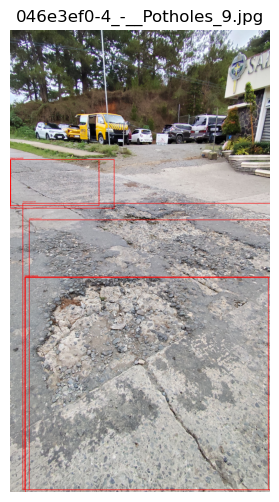

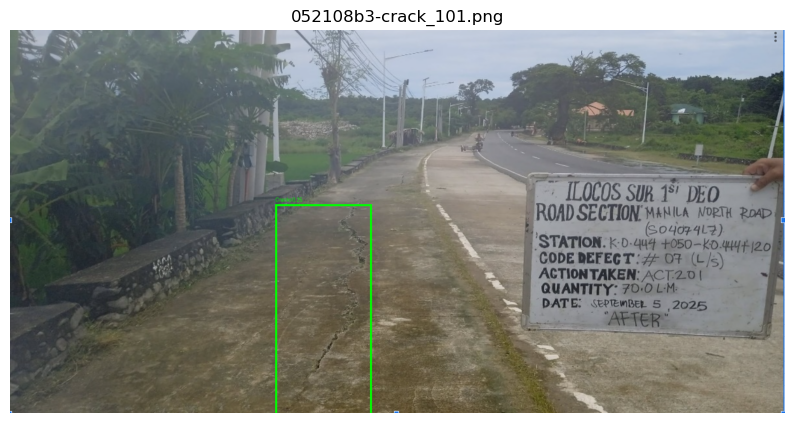

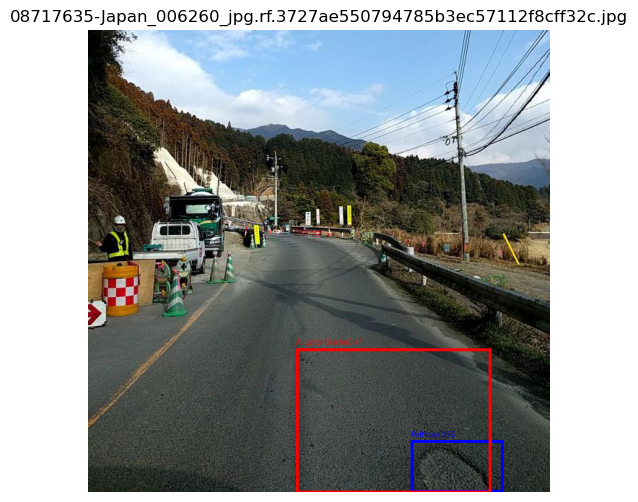

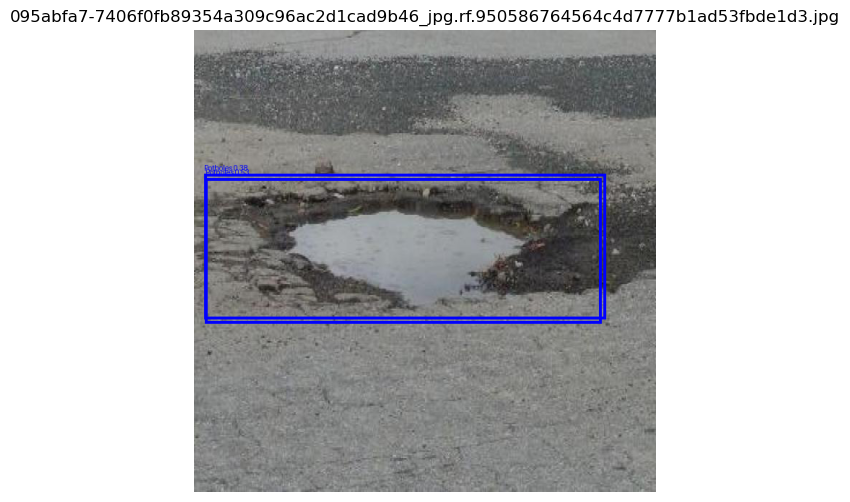

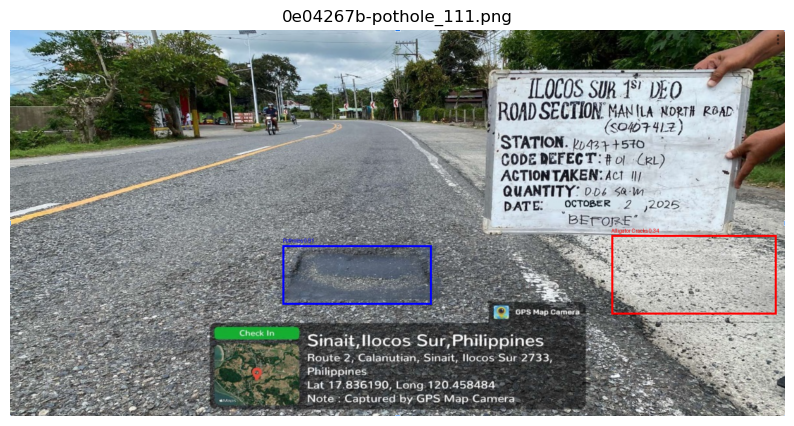

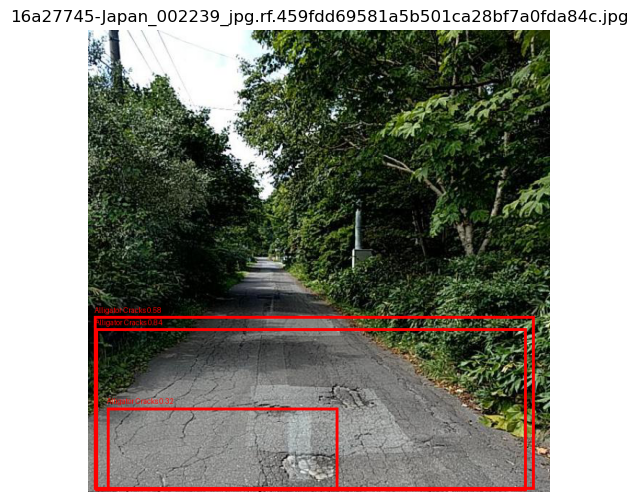

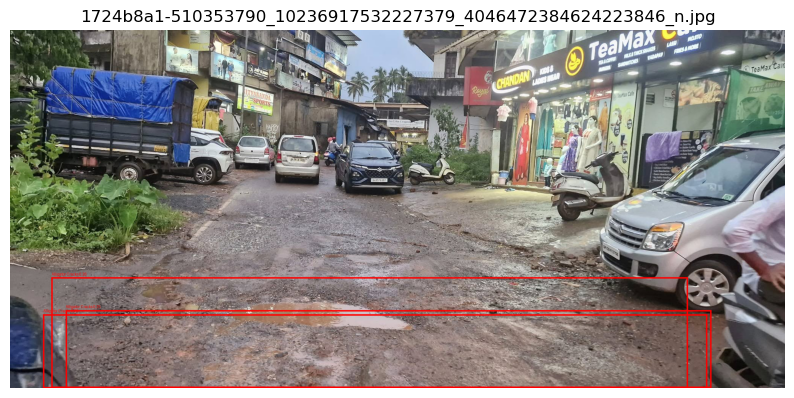

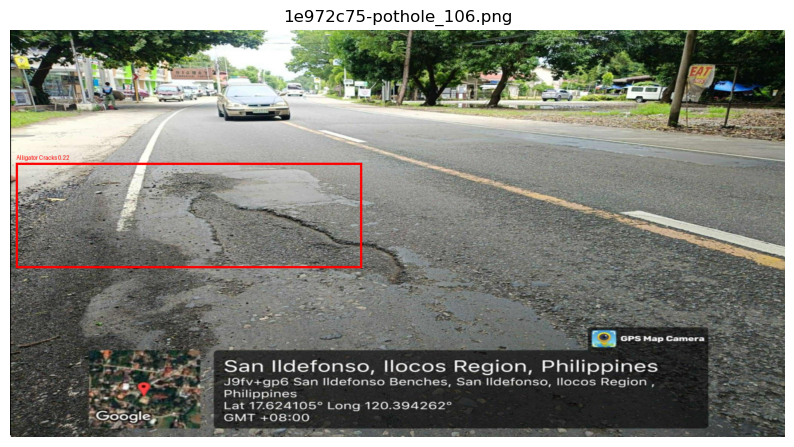

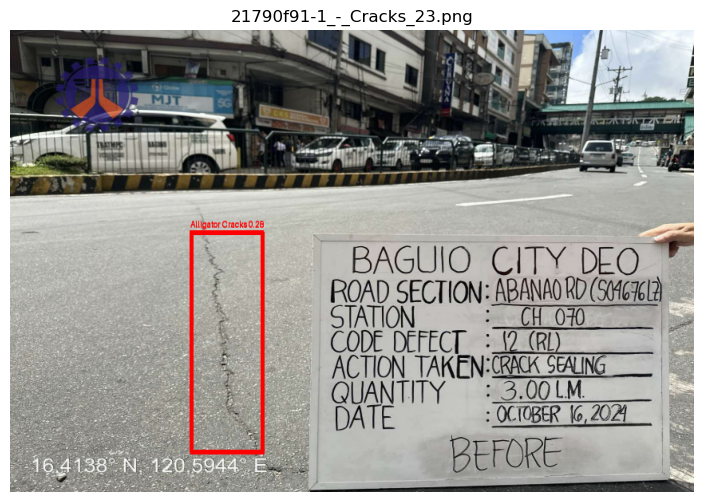

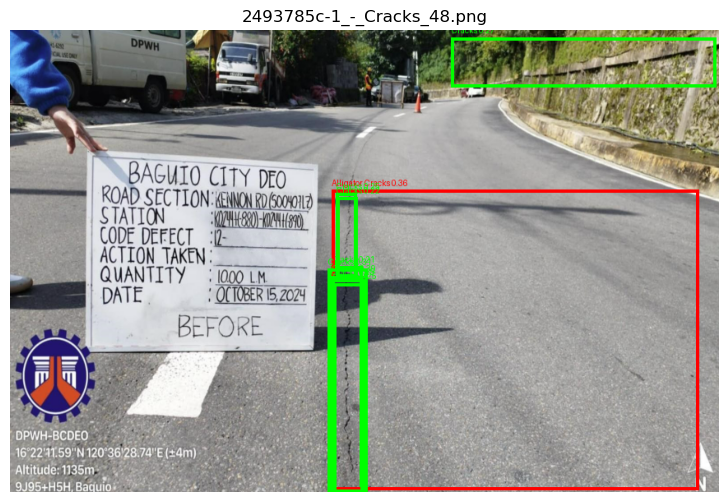

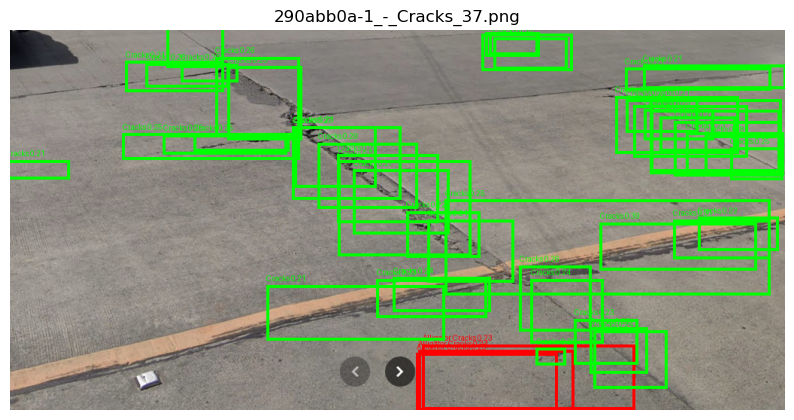

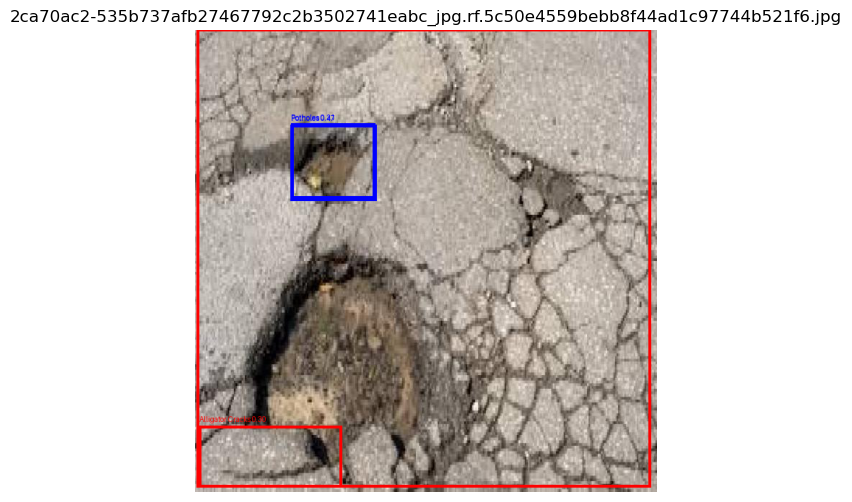

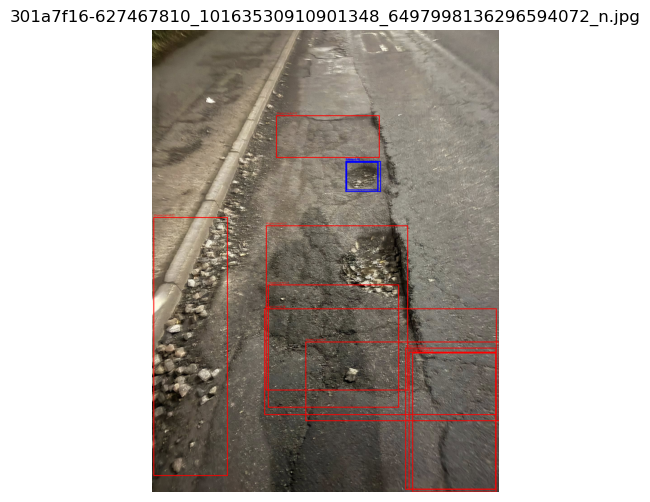

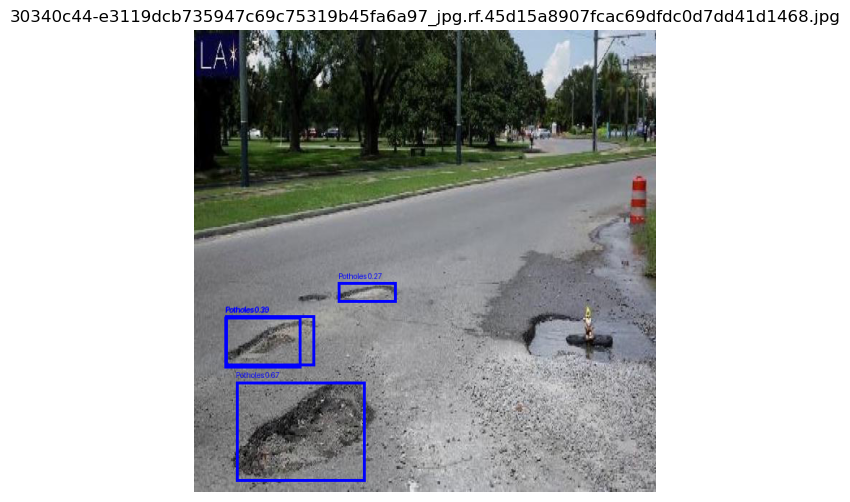

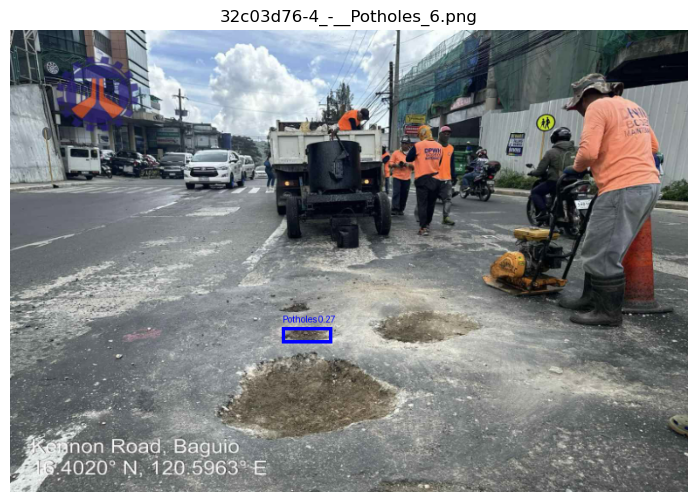

In [43]:
import sys
import os
import torch
import numpy as np
from PIL import Image, ImageDraw, UnidentifiedImageError
import matplotlib.pyplot as plt

# 1. SETUP ROOT PATHS
ROOT = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

from src.core import YAMLConfig
import src.zoo.rtdetr.rtdetr 
import src.solver

# 2. PATHS
CONFIG_NAME = 'rtdetrv2_r50vd_m_7x_coco.yml'
CONFIG_PATH = os.path.join(ROOT, 'configs', 'rtdetrv2', CONFIG_NAME)
MODEL_PATH = os.path.join(ROOT, 'output', 'rtdetrv2_r50vd_m_6x_coco', 'best.pth')
TEST_IMAGE_DIR = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\Final_Dataset\test\images'

# 3. LOAD MODEL
cfg = YAMLConfig(CONFIG_PATH, resume=MODEL_PATH)
model = cfg.model
checkpoint = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint.get('model', checkpoint), strict=False)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 4. PREDICTION FUNCTION
def display_test_results(image_dir, num_images=15, threshold=0.20):
    all_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # CORRECTED 4-CLASS MAP - MATCHES YOUR JSON
    class_map = {
        0: "Alligator Cracks", 
        1: "Cracks", 
        2: "Potholes", 
        3: "Ravelling"
    }
    colors = ["red", "lime", "blue", "yellow"]
    
    displayed_count = 0

    for img_path in all_files:
        if displayed_count >= num_images:
            break
            
        try:
            img_pil = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError):
            continue 

        original_w, original_h = img_pil.size
        input_tensor = torch.from_numpy(np.array(img_pil.resize((640, 640)))).permute(2, 0, 1).float() / 255.0
        
        with torch.no_grad():
            if hasattr(model, 'deploy'):
                model.deploy = True
            outputs = model(input_tensor.unsqueeze(0).to(device), 
                            torch.tensor([[original_h, original_w]]).to(device))

        if isinstance(outputs, dict):
            logits = outputs.get('pred_logits', outputs.get('logits'))
            boxes_raw = outputs.get('pred_boxes', outputs.get('boxes'))
            probs = logits.sigmoid()
            scores, labels = torch.max(probs, dim=-1)
            boxes = boxes_raw
        else:
            labels, boxes, scores = outputs

        draw = ImageDraw.Draw(img_pil)
        
        curr_labels = labels[0].cpu().numpy()
        curr_boxes = boxes[0].cpu().numpy()
        curr_scores = scores[0].cpu().numpy()

        for i, s in enumerate(curr_scores):
            if s > threshold:
                cid = int(curr_labels[i])
                
                # Check if the class ID exists in our 4-class map
                if cid in class_map:
                    label_name = class_map[cid]
                    color = colors[cid] if cid < len(colors) else "red"
                    
                    box = curr_boxes[i]
                    if box[2] <= 1.1 and box[3] <= 1.1:
                        cx, cy, bw, bh = box
                        coords = [(cx-bw/2)*original_w, (cy-bh/2)*original_h, (cx+bw/2)*original_w, (cy+bh/2)*original_h]
                    else:
                        coords = box.tolist()
                    
                    draw.rectangle(coords, outline=color, width=4)
                    draw.text((coords[0], coords[1]-15), f"{label_name} {s:.2f}", fill=color)

        plt.figure(figsize=(10, 6))
        plt.imshow(img_pil)
        plt.title(f"{os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()
        
        displayed_count += 1

display_test_results(TEST_IMAGE_DIR, num_images=15)